# Risk and Decision-Making for Data Science and AI

#Semester B Coursework, 2026

#Question 1
A university is studying factors affecting student academic performance. From prior research and domain knowledge, the following relationships are believed to hold:

• Students with higher “Intelligence” tend to study more.

• Higher “Motivation” increases “StudyHours”.

• Poor “Sleep” increases “Stress”.

• High “StudyHours” improves “Grade”.

• High “Stress” reduces “Grade”.

• Low “Sleep” increases “Stress” and directly harms “Grade”.

All variables are binary:

• Intelligence: high/low

• Motivation: high/low

• StudyHours: high/low

• Sleep: good/poor

• Stress: high/low

• Grade: good/poor



**Qa)** Using the above story, draw a Bayesian network (BN) DAG. Use Pyagrum.
Provide your code and the BN structure.


**Answer:** A Bayesian Network (BN) consists of two parts, a Directed Acyclic Graph (DAG) with arrows and nodes, and a local Conditional Probability Table (CPT) for each node. The diagram below is a Bayesian Network (BN) DAG where the arrows express conditional dependencies and represents causal directions (cause to effect). In this DAG the relationship between the variables is shown in 6 arcs. For example, Intelligence (cause) Study Hours (effect). Motivation Study hours, Sleep Stress, Study Hours Grade, Stress Grade, Sleep Grade. The BN structure results shows that Study Hours is a collider between Motivation and Intelligence and Grade is a collider and has arrows from the three parent nodes Sleep, Stress and Study Hours. Lastly, Sleep is a common cause of Grade and Stress.

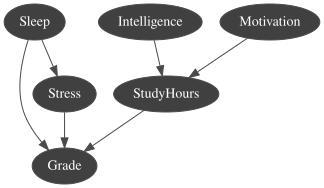

In [ ]:
!pip install pyagrum

# Import libraries and visualisation DONE
import pyagrum as gum
import pyagrum.lib.notebook as gnb

# Create a Bayesian Network (BN)
bn = gum.BayesNet('Student Performance')

# Add nodes and assign variables
Intelligence = bn.add(gum.LabelizedVariable('Intelligence', 'Intelligence', ["low", "high"]))
Motivation = bn.add(gum.LabelizedVariable('Motivation', 'Motivation', ["low", "high"]))
StudyHours = bn.add(gum.LabelizedVariable('StudyHours', 'StudyHours', ["low", "high"]))
Sleep = bn.add(gum.LabelizedVariable('Sleep', 'Sleep', ["good", "poor"]))
Stress = bn.add(gum.LabelizedVariable('Stress', 'Stress', ["low", "high"]))
Grade = bn.add(gum.LabelizedVariable('Grade', 'Grade', ["good", "poor"]))

# Add arcs
bn.addArc(Intelligence, StudyHours)
bn.addArc(Motivation, StudyHours)
bn.addArc(Sleep, Stress)
bn.addArc(StudyHours, Grade)
bn.addArc(Stress, Grade)
bn.addArc(Sleep, Grade)

# Display the BN structure
gnb.showBN(bn)

**Qb)** Use the dataset “students_bn_dataset_50” to train the model’s parameters.
Use Pyagrum. Provide a screenshot of the code, screenshots of the conditional
probability tables, and the results of the BN structure with the parameters.


**Answer:** In this section the dataset ‘student_bn_datasets_50’ is used to train the models parameters. Lecture 7 states that data is used to learn the model’s parameters by counting the occurrences of each variable state and combinations of variables states in the data. Also, the prior probabilities are defined with parameter learning. The results of the three root nodes are: Intelligence (low=0.38, high=0.62), Motivation (low=0.60, high=0.40) and Sleep (poor=0.24, good=0.76). The results of the conditional dependencies shows that Study Hours (child node) is driven by Motivation and Intelligence (parent nodes). When Intelligence and Motivation are both low, Study Hours is at its lowest (0.23) where as when both parents are high Study Hours significantly increases to 0.71. When Sleep is good, high Stress is 0.34 where as poor sleep increases high Stress (0.66). Grade=good is 0.00 (given poor Sleep, low Stress, low Study Hours) but increases to 0.92 (when given good Sleep, low Stress, high Study Hours). The inference diagram shows the prior marginals (Study Hours= high 54.99%, Stress=high 42.00%, Grade=good 57.97%.


In [ ]:
# Upload data DONE
from google.colab import files
uploaded = files.upload()

Saving student_bn_dataset_50.csv to student_bn_dataset_50 (1).csv


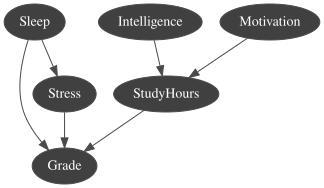

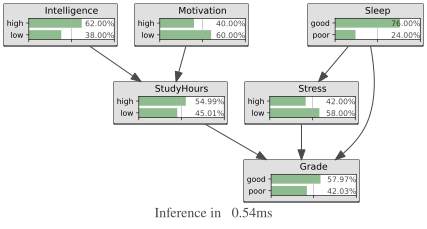

In [ ]:
# Import library
import pandas as pd

# Upload data
file_path = 'student_bn_dataset_50.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

# Learn parameters from data
learner = gum.BNLearner(df)
bn = learner.learnParameters(bn)

# Conditional probability tables
gnb.sideBySide(bn.cpt('Intelligence'), bn.cpt('Motivation'), bn.cpt('Sleep'))
gnb.sideBySide(bn.cpt('StudyHours'))
gnb.sideBySide(bn.cpt('Stress'))
gnb.sideBySide(bn.cpt('Grade'))

# BN structure with parameters
gnb.showBN(bn)

gnb.showInference(bn)



**Qc)** From the above story, we know that “Intelligence” does not affect your
“Motivation” to study. However, when looking at those with high “Study hours”,
having low “Intelligence” makes someone more willing to study more. Explain
why these relationships happen (use both the BN structure and the model
reasoning/inference). Use Pyagrum. Provide a screenshot of the code.

**Answer:** The reason why both relationships happen is because Study Hour is a common effect (a collider) of Motivation and Intelligence. According to Lecture 3, Colliders Bias occurs when an exposure and outcome independently cause a third variable. The Bayesian Network DAG shows that Motivation and Intelligence are parent nodes of the child node Study Hours (common effect). They do not have an arc between them, and they only share one node. As no evidence is observed and the path between them is blocked, both nodes (Motivation and Intelligence) are mutually independent. The inference graphs below confirms this, P(Motivation=high) stays the same at 0.40 whether Intelligence is low or high. However, this path becomes unblocked when we condition on Study Hours=high. This is also known as the explaining away effect, where high study hours are explained by either high motivation or high
3 intelligence and as we learned from the question ("having low intelligence") that leaves motivation as the cause. The results demonstrate this in Study Hours= high, P(Motivation=high) is 0.4474 at Intelligence=high however increases to 0.6582 when Intelligence=low. This is further evident in the inference diagram where Motivation=high is 65.82% given low Intelligence however 44.74% given Intelligence high. Furthermore lecture 3 states that controlling for a collider can induce a distorted association between outcome and exposure, which was evident here.


In [ ]:
# Set up the inference engine
ie = gum.LazyPropagation(bn)

In [ ]:
# P(Motivation) with no evidence
ie.setEvidence({})
ie.makeInference()
ie.posterior('Motivation')

(pyagrum.Tensor@0x311afff0) 
  Motivation       │
high     │low      │
─────────│─────────│
 0.4000  │ 0.6000  │

In [ ]:
# P(Motivation | Intelligence = high)
ie.setEvidence({'Intelligence': 'high'})
ie.makeInference()
ie.posterior('Motivation')

(pyagrum.Tensor@0x311d77d0) 
  Motivation       │
high     │low      │
─────────│─────────│
 0.4000  │ 0.6000  │

In [ ]:
# P(Motivation | Intelligence = low)
ie.setEvidence({'Intelligence': 'low'})
ie.makeInference()
ie.posterior('Motivation')

(pyagrum.Tensor@0x312b1a00) 
  Motivation       │
high     │low      │
─────────│─────────│
 0.4000  │ 0.6000  │

In [ ]:
# StudyHours = high, Intelligence = high
ie.setEvidence({'StudyHours': 'high', 'Intelligence': 'high'})
ie.makeInference()
ie.posterior('Motivation')

(pyagrum.Tensor@0x30a355c0) 
  Motivation       │
high     │low      │
─────────│─────────│
 0.4474  │ 0.5526  │

In [ ]:
# StudyHours = high, Intelligence = low
ie.setEvidence({'StudyHours': 'high', 'Intelligence': 'low'})
ie.makeInference()
ie.posterior('Motivation')

(pyagrum.Tensor@0x31089900) 
  Motivation       │
high     │low      │
─────────│─────────│
 0.6582  │ 0.3418  │

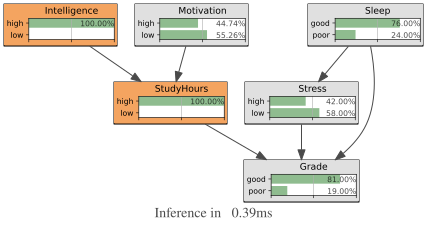

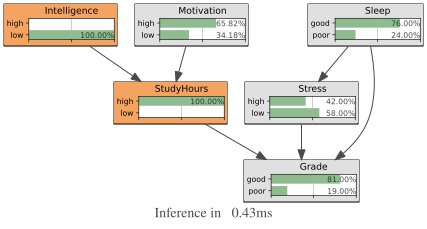

In [ ]:
# Visual inference on the network
gnb.showInference(bn, evs={'StudyHours': 'high', 'Intelligence': 'high'})
gnb.showInference(bn, evs={'StudyHours': 'high', 'Intelligence': 'low'})

**Qd)** What is the probability that Alice, who is a highly intelligent but a low-motivated
student who has bad sleep habits, will have good grades? Use Pyagrum.
Provide a screenshot of the code.

**Answer:** In lecture 3 we studied Pearl’s ladder of causation and rung 1 is association or in other words seeing (“What if I see...”), which is the approach in this task. I won’t make any changes, but I will observe three of Alice’s traits. I start by setting the evidence (Intelligence: high, Motivation: low, Sleep: poor), then I compute the inference and posterior. The results show
4
Grade=poor is 0.5529 and Grade=good is 0.4471. The probability that Alice will have good grades is 44.71%, meaning she is more likely to get a poor grade than a good grade. Although Alice's high Intelligence assists her, the low Motivation decreased her chance of higher Study Hours. Additionally, Alice's poor sleep shows that it increased her Stress (Stress=high is 66.67%) as well as directly impacting her Grade (Grade=poor is 55.29%). This is consistent in the inference visualisation where Grade=good is 44.71%, Study Hours=high is 58.82% (Intelligence=high and Motivation=low).

In [ ]:
# Evidence: highly intelligent, low motivation, bad sleep
ie.setEvidence({'Intelligence': 'high', 'Motivation': 'low', 'Sleep': 'poor'})
ie.makeInference()
ie.posterior('Grade')


(pyagrum.Tensor@0x30c9d210) 
  Grade            │
good     │poor     │
─────────│─────────│
 0.4471  │ 0.5529  │

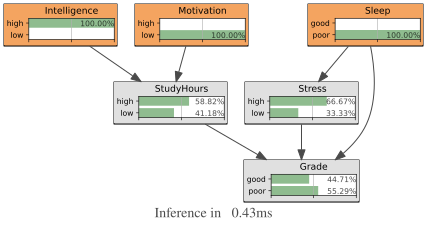

In [ ]:
#Visual inference
gnb.showInference(bn, evs={'Intelligence': 'high', 'Motivation': 'low', 'Sleep': 'poor'})

**Qe)** Alice had bad grades, and you are wondering whether her grades would have
been good if either her motivation had been higher or her sleep had been better.
Which action could have had the most positive impact? Explain the reasoning
process. Use Pyagrum. Provide a screenshot of the code

**Answer:** The approach in this task is counterfactual, which is reasoning about alternative outcomes. In this type of reasoning, we make observations about what actually happened. I start by setting up the causal model, then adding Alice's actual real-world profile (counterfactual is conditioned on all the information we already know) once 'what if' is given a value we can evaluate how her Grades would be impacted by the change in factors. Counterfactual 1 (what if Alice's Motivation had been high), the probability of a good grade given her motivation is high is 51.43%, where are previously it was 44.71%. Counterfactual 2 (what if Alice's sleep had been good?), the probability of a good grade given her sleep being good is 64.74%. Overall, the results show that good sleep would have had a larger impact on Alice's grade rather than high motivation. Further this is evident in the BN structure where Sleep has two routes to grade (direct Sleep to Grade or indirectly through Stress then to Grade), however Motivation has one indirect route (Study Hours to Grade).

In [ ]:
# Set up the causal model
import pyagrum.causal as csl

cm = csl.CausalModel(bn)


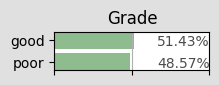

In [ ]:
# Counterfactual 1: What if Alice's MOTIVATION had been high?
pot_motivation = csl.counterfactual(
    cm = cm,
    profile = {'Intelligence': 'high', 'Motivation': 'low', 'Sleep': 'poor', 'Grade': 'poor'},
    whatif = {'Motivation'},
    on = {'Grade'},
    values = {'Motivation': 'high'})

gnb.showProba(pot_motivation)


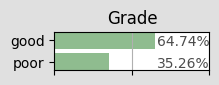

In [ ]:
# Counterfactual 2: What if Alice's SLEEP had been good?
pot_sleep = csl.counterfactual(
    cm = cm,
    profile = {'Intelligence': 'high', 'Motivation': 'low', 'Sleep': 'poor', 'Grade': 'poor'},
    whatif = {'Sleep'},
    on = {'Grade'},
    values = {'Sleep': 'good'})

gnb.showProba(pot_sleep)

**Qf)** What is the causal impact that high stress has on grades for students with high
intelligence and high motivation? Explain the reasoning process. Use Pyagrum.
Provide a screenshot of the code.

**Answer:** The approach in the task is the intervention reasoning, which removes any causal factors in the variable you intervene on, and the only cause is you. This is Rung 2 of the Pearl's ladder of causation in lecture 3 (Doing: "What if I do"). I used to interventions from the same group to measure the impact of high stress (Stress=high and Stress=low). The results show do(Stress=high): P(Grade=good)= 0.6243 and for do(Stress=low): P(Grade=good)= 0.6776. For students with high Motivation and high Intelligence, the causal impact of high stress in good grades is 5.3% (0.6776 - 0.6243 = 0.0533). Overall, this value suggests that for students with high Motivation and Intelligence, high stress decreases the probability of receiving good grades (by 5.3%) compared to low stress students.

In [ ]:
#Causal impact of high Stress on Grade
import pyagrum.causal as csl

# Build the causal model
cm = csl.CausalModel(bn)

# do(Stress = high)
csl.causalImpact(cm, on='Grade', doing='Stress',
                 knowing={'Intelligence', 'Motivation'},
                 values={'Stress': 'high', 'Intelligence': 'high', 'Motivation': 'high'})[1]

(pyagrum.Tensor@0x31407a40) 
  Grade            │
good     │poor     │
─────────│─────────│
 0.6243  │ 0.3757  │

In [ ]:
# Compare with do(Stress = low)
csl.causalImpact(cm, on='Grade', doing='Stress',
                 knowing={'Intelligence', 'Motivation'},
                 values={'Stress': 'low', 'Intelligence': 'high', 'Motivation': 'high'})[1]

(pyagrum.Tensor@0x31251ee0) 
  Grade            │
good     │poor     │
─────────│─────────│
 0.6776  │ 0.3224  │

# Question 2
A group of data scientists considered a song to be successful if it reached 1 million
plays worldwide within six months of release. They built an AI model to predict this
outcome. They validated the model on a test set of 20 songs released six months ago,
10 of which had reached one million plays and 10 had not. The dataset, including the
true outcomes and the model’s predictions, is provided as “song_success_20.”

**Qa)** Based on the data available at “song_success_20”, complete the following
tables

In [ ]:
# Upload data
from google.colab import files
uploaded = files.upload()

Saving song_success_20.csv to song_success_20 (1).csv


In [ ]:
# Import library
import pandas as pd

# Upload data
file_path = 'song_success_20.csv'
df = pd.read_csv(file_path)

# Clean up the column names
df.columns = ['SongID', 'TrueSuccess', 'PredYes']

df

,SongID,TrueSuccess,PredYes
0,S01,No,0.25
1,S02,Yes,0.60
2,S03,Yes,0.95
3,S04,No,0.55
4,S05,No,0.05
5,S06,Yes,0.70
6,S07,No,0.25
7,S08,Yes,0.90
8,S09,Yes,0.40
9,S10,Yes,0.85


In [ ]:
# Import library
import pandas as pd

# Upload data
file_path = 'song_success_20.csv'
df = pd.read_csv(file_path)

# Clean up the column names
df.columns = ['SongID', 'TrueSuccess', 'PredYes']

# Thresholds for P(Success=Yes)
thresholds = [0.1, 0.5, 0.7, 0.9]

df

,SongID,TrueSuccess,PredYes
0,S01,No,0.25
1,S02,Yes,0.60
2,S03,Yes,0.95
3,S04,No,0.55
4,S05,No,0.05
5,S06,Yes,0.70
6,S07,No,0.25
7,S08,Yes,0.90
8,S09,Yes,0.40
9,S10,Yes,0.85


In [ ]:
# Confusion matrix: TN, FP, FN, TP

for t in thresholds:
    TP = len(df[(df['TrueSuccess'] == 'Yes') & (df['PredYes'] >= t)])
    FN = len(df[(df['TrueSuccess'] == 'Yes') & (df['PredYes'] <  t)])
    TN = len(df[(df['TrueSuccess'] == 'No')  & (df['PredYes'] <  t)])
    FP = len(df[(df['TrueSuccess'] == 'No')  & (df['PredYes'] >= t)])

    print(f"Threshold = {t}")
    print(f"                        Pred Yes < {t}    Pred Yes >= {t}")
    print(f"  True success = No        {TN:>2} (TN)        {FP:>2} (FP)")
    print(f"  True success = Yes       {FN:>2} (FN)        {TP:>2} (TP)")
    print()

Threshold = 0.1
                        Pred Yes < 0.1    Pred Yes >= 0.1
  True success = No         1 (TN)         9 (FP)
  True success = Yes        0 (FN)        10 (TP)

Threshold = 0.5
                        Pred Yes < 0.5    Pred Yes >= 0.5
  True success = No         8 (TN)         2 (FP)
  True success = Yes        1 (FN)         9 (TP)

Threshold = 0.7
                        Pred Yes < 0.7    Pred Yes >= 0.7
  True success = No         9 (TN)         1 (FP)
  True success = Yes        5 (FN)         5 (TP)

Threshold = 0.9
                        Pred Yes < 0.9    Pred Yes >= 0.9
  True success = No         9 (TN)         1 (FP)
  True success = Yes        7 (FN)         3 (TP)



**Qb)** Calculate the sensitivity, specificity, and accuracy of the model for the
P(Success=Yes) threshold of 0.1, 0.5, 0.7, and 0.9.

**Answer:** In this task I computed the four thresholds using the three evaluation metrics sensitivity, specificity and accuracy. The results are threshold 0.1 (sensitivity=1.00, specificity=0.10, accuracy=0.55 ), threshold 0.5 (sensitivity=0.90, specificity=0.80, accuracy=0.85), threshold 0.7 (sensitivity=0.50, specificity=0.90, accuracy=0.70) and threshold 0.9 (sensitivity=0.30, specificity=0.90, accuracy=0.60). 0.5 is the most balanced and highest achieving accuracy (0.85).

In [ ]:
#   sensitivity= TP / (TP + FN)
#   specificity= TN / (TN + FP)
#   accuracy= (TP + TN) / (TP + TN + FP + FN)

for t in thresholds:
    TP = len(df[(df['TrueSuccess'] == 'Yes') & (df['PredYes'] >= t)])
    FN = len(df[(df['TrueSuccess'] == 'Yes') & (df['PredYes'] <  t)])
    TN = len(df[(df['TrueSuccess'] == 'No')  & (df['PredYes'] <  t)])
    FP = len(df[(df['TrueSuccess'] == 'No')  & (df['PredYes'] >= t)])

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    accuracy    = (TP + TN) / (TP + TN + FP + FN)

    print(f"Threshold = {t}:  sensitivity = {sensitivity:.2f}, "
          f"specificity = {specificity:.2f}, accuracy = {accuracy:.2f}")

Threshold = 0.1:  sensitivity = 1.00, specificity = 0.10, accuracy = 0.55
Threshold = 0.5:  sensitivity = 0.90, specificity = 0.80, accuracy = 0.85
Threshold = 0.7:  sensitivity = 0.50, specificity = 0.90, accuracy = 0.70
Threshold = 0.9:  sensitivity = 0.30, specificity = 0.90, accuracy = 0.60


**Qc)** Plot the ROC (receiver-operator characteristics) curve for the model based on
the four thresholds of P(Success=Yes) given above (0.1, 0.5, 0.7, 0.9). Provide
an interpretation of the ROC curve. At which threshold does the classifier
perform best, and why?

**Answer:** This task computes the ROC curve, plotting the false positive rate (1-sepcificity) on the x-axis and the true positive rate (sensitivity) is plotted on the y-axis. The blue model ROC line represents the point of each of the four thresholds (0.9, 0.7, 0.5, 0.1) and the orange coin flip line represents random classifiers. As stated in Lecture 8 ROC (Receiver Operator Characteristic) is used to evaluate a model’s performance whilst considering the specificity and sensitivity as various thresholds. This graph is a visual representation of a good classifier as the threshold increased the curve becomes closer to ROC curve of a perfect prediction model (as stated in lecture example), then points to the right at threshold=1. Threshold 0.5 is when the classifier performs its best at, this is because it was top left corner (perfect prediction line). At threshold 0.5 the model achieves a specificity of 0.80, sensitivity of 0.90 and 0.85 for accuracy (the highest amongst the four thresholds).

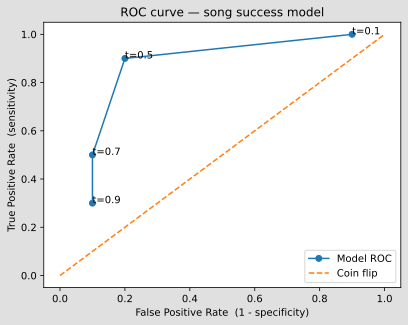

In [ ]:
# Code cell
import matplotlib.pyplot as plt

# Build the ROC points (1 - specificity, sensitivity)
fpr = []
tpr = []

for t in thresholds:
    TP = len(df[(df['TrueSuccess'] == 'Yes') & (df['PredYes'] >= t)])
    FN = len(df[(df['TrueSuccess'] == 'Yes') & (df['PredYes'] <  t)])
    TN = len(df[(df['TrueSuccess'] == 'No')  & (df['PredYes'] <  t)])
    FP = len(df[(df['TrueSuccess'] == 'No')  & (df['PredYes'] >= t)])

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    tpr.append(sensitivity)
    fpr.append(1 - specificity)

# Sort points by x so the curve is drawn left-to-right
points = sorted(zip(fpr, tpr))
fpr_sorted = [p[0] for p in points]
tpr_sorted = [p[1] for p in points]

# Plot the ROC curve
plt.figure()
plt.plot(fpr_sorted, tpr_sorted, marker='o', label='Model ROC')
plt.plot([0, 1], [0, 1], linestyle='--', label='Coin flip')
plt.xlabel('False Positive Rate  (1 - specificity)')
plt.ylabel('True Positive Rate  (sensitivity)')
plt.title('ROC curve — song success model')
plt.legend()

# Annotate each point with its threshold
for t, x, y in zip(thresholds, fpr, tpr):
    plt.annotate(f"t={t}", (x, y))

plt.show()

# Question 3

**Qa)** A public-health study investigated whether night-time screen exposure is
associated with clinically significant cognitive fatigue among shift workers.
Participants were classified by:
• High exposure: ≥3 hours/night screen use
• Low exposure: < 3 hours/night
Researchers also recorded shift type, known to affect fatigue risk. The observed data
can be found at “shift_screen_fatigue_1200”.
{“fatigue = 0” indicates “No fatigue”, “fatigue = 1” indicates “Fatigue”, “screen exposure
= 0” indicates “low exposure”, “screen exposure = 1” indicates “high exposure”}

**i)** What is the absolute increase in risk of fatigue for high vs low exposure?

**Answer:** According to lecture 6, the absolute risk of something happening is the odds of that happening over a stated period. It is calculated by dividing the number of instances and the total number of people in the group. The results show absolute risk (high exposure) is 35.00% and the absolute risk (low exposure) is 25.00%. The absolute increase in risk (the difference between high and low) is 10.00%.

In [ ]:
# Upload data
from google.colab import files
uploaded = files.upload()

Saving shift_screen_fatigue_1200.csv to shift_screen_fatigue_1200 (2).csv


In [ ]:
# Code cell
import pandas as pd

# Load dataset
df = pd.read_csv('shift_screen_fatigue_1200.csv')

# Absolute risk
def calculate_absolute_risk(num_cases, total_people):
    return (num_cases / total_people) * 100

# High exposure and low exposure group
high = df[df['screen_high'] == 1]
low  = df[df['screen_high'] == 0]

# Number of fatigue cases and group sizes
cases_high = high['fatigue'].sum()
cases_low  = low['fatigue'].sum()
total_high = len(high)
total_low  = len(low)

# Absolute risk in each group
absolute_risk_high = calculate_absolute_risk(cases_high, total_high)
absolute_risk_low  = calculate_absolute_risk(cases_low,  total_low)

# Absolute increase in risk (high vs low)
absolute_risk_increase = absolute_risk_high - absolute_risk_low

# Display the results
print(f"Absolute Risk (high exposure): {absolute_risk_high:.2f}%")
print(f"Absolute Risk (low exposure):  {absolute_risk_low:.2f}%")
print(f"Absolute increase in risk (high vs low): {absolute_risk_increase:.2f}%")

Absolute Risk (high exposure): 35.00%
Absolute Risk (low exposure):  25.00%
Absolute increase in risk (high vs low): 10.00%


**ii)** What is the relative increase in risk of fatigue for those with high screen
exposure compared to those with low screen exposure? Provide a full answer
(including interpretation)

**Answer:** According to lecture 6, the relative risk of something happening is where you compare the odds for two groups against one another. It is calculated by dividing the risk of exposed groups by the risk of unexpected group. The results of the relative risk (high vs low exposure) are 1.40, this was determined by dividing absolute risk (high) / absolute risk (low) = 35.00% / 25.00% = 1.40. As a result, someone with a high screen exposure is 1.4 times as likely to fatigue than people who doesn't. Additionally relative risk results can have an exaggerated perception of risk, which is why it is important to remember that although the relative increased risk is 40.00%, there was only a 10.00% absolute risk increase from low exposure to high exposure.

In [ ]:
# Relative risk function
def calculate_relative_risk(risk_exposed, risk_unexposed):
    return risk_exposed / risk_unexposed

# Relative risk: high exposure vs low exposure
relative_risk = calculate_relative_risk(absolute_risk_high, absolute_risk_low)

# Relative increase in risk
relative_increase = (relative_risk - 1) * 100

# Display the results
print(f"Relative Risk (high vs low exposure): {relative_risk:.2f}")
print(f"Relative increase in risk: {relative_increase:.2f}%")

Relative Risk (high vs low exposure): 1.40
Relative increase in risk: 40.00%


**iii)** Does shift type confound the association between screen exposure and
fatigue? Justify your answer.

**Answer:** No shift type does not confound the association between fatigue and screen exposure. According to lecture 3 confounding happens when an outcome and exposure have a shared common cause. Condition 1 looks at whether shift is associated outcome (fatigue). The results indicate that yes it does as the fatigue rate in night shift is 46.00% (0.460000) and for day shift it is 18.57% (0.185714), which indicates that shift type is significantly associated with fatigue rate. Condition 2 looks at whether shift is associated with exposure (screen use). The results indicate that no it doesn't as both day and night shift types are 50% (0.5). Shift type is not a confounder of the fatigue and screen associate, to be a confounder both outcome and exposure need to be a common cause whereas here only condition 1 (fatigue) is only associated with shift. Lecture 3 states that confounding bias can be avoided with stratification, where data is isolated into sub groups of potential confounders. In this case shift was stratified and the results show day shift absolute risk difference (high vs low) is 2.86% and night shift absolute risk difference (high vs low) is 20.00%. Lecture 3 states the purpose of this is investigate the relation within control and strata, however this result shows screen exposure does not disappear when we control shift type.

In [ ]:
import pandas as pd

df = pd.read_csv('shift_screen_fatigue_1200.csv', encoding='utf-8-sig')

# Is shift associated with the outcome (fatigue)?
print("Fatigue rate by shift type:")
print(df.groupby('shift')['fatigue'].mean())
print()

# Is shift associated with the exposure (screen use)?
print("Screen exposure rate by shift type:")
print(df.groupby('shift')['screen_high'].mean())
print()

# Stratify: fatigue risk by exposure, within each shift
print("Fatigue rate by exposure, stratified by shift type:")
strat = df.groupby(['shift', 'screen_high'])['fatigue'].mean()
print(strat)
print()

# Risk difference (high vs low exposure) within each shift
day_ard   = (strat['Day'][1] - strat['Day'][0]) * 100
night_ard = (strat['Night'][1] - strat['Night'][0]) * 100
print(f"Day shift absolute risk difference (high vs low): {day_ard:.2f}%")
print(f"Night shift absolute risk difference (high vs low): {night_ard:.2f}%")

Fatigue rate by shift type:
shift
Day      0.185714
Night    0.460000
Name: fatigue, dtype: float64

Screen exposure rate by shift type:
shift
Day      0.5
Night    0.5
Name: screen_high, dtype: float64

Fatigue rate by exposure, stratified by shift type:
shift  screen_high
Day    0              0.171429
       1              0.200000
Night  0              0.360000
       1              0.560000
Name: fatigue, dtype: float64

Day shift absolute risk difference (high vs low): 2.86%
Night shift absolute risk difference (high vs low): 20.00%


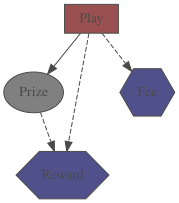

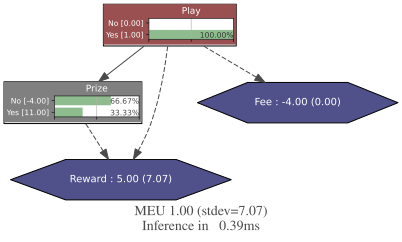

In [ ]:
# CPT for Prize
idg.cpt(prize)[{'Play': 0}] = [1.0, 0.0]
idg.cpt(prize)[{'Play': 1}] = [2/3, 1/3]

# Utility of the Reward
idg.utility(reward)[{'Play': 0, 'Prize': 0}] = 0
idg.utility(reward)[{'Play': 0, 'Prize': 1}] = 0
idg.utility(reward)[{'Play': 1, 'Prize': 0}] = 0
idg.utility(reward)[{'Play': 1, 'Prize': 1}] = 15

# Utility of the Fee
idg.utility(fee)[{'Play': 0}] = 0
idg.utility(fee)[{'Play': 1}] = -4

# Display the influence diagram
gnb.showInfluenceDiagram(idg)
gnb.showInference(idg)